# Yield comparison across crops — NUTS-3, state & yearly scale

Compare **observed vs simulated** yield for all five calibrated crops in a single
notebook, using the baseline DWD simulation on soil scenario **S1**.

Observed yield is reported at the **district (NUTS-3) level** (one value per
`NUTS_ID` and year), while the simulation is run **per agricultural point**. So
the simulated point-year yields are first aggregated to the district level (mean
over the points that fall inside each `NUTS_ID`, via `point_to_nearest_grid.csv`)
and then merged with the observed district yields on `NUTS_ID` + `year`.

The merged district-year table is then evaluated at three spatial/temporal scales:

1. **NUTS-3 scale** — per-district climatology (mean over years): does the model
   reproduce the _spatial_ yield pattern across districts?
2. **State scale** — mean yield per federal state (`STATE_NAME`).
3. **Yearly scale** — mean yield per year across all districts: does the model
   track _inter-annual_ variability?

The simulation selection is fully flexible: change `SIM_NAME` below to any run
folder under `<crop>/runs/` (e.g. `DWD__S2`, `DWD__DL`, or a future climate run)
and re-run to evaluate that scenario.

> **Units note.** The simulated `Yield_t_ha` is **dry-matter** yield. Observed
> cereal/rapeseed yields are near dry-matter, but the observed **potato** yield
> is **fresh tuber weight** (~30 t/ha vs ~4 t/ha dry). Use `DM_FRACTION` below to
> put a crop's observed values on the simulated (dry-matter) basis before
> comparison; the default leaves values unchanged and the mismatch is visible in
> the bias.


## Configuration


In [1]:
import os
from concurrent.futures import ThreadPoolExecutor
from glob import glob
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm

plt.rcParams["font.family"] = "DeJavu Serif"
plt.rcParams["font.serif"] = "Times New Roman"

# ---------------------------------------------------------------------------
# Flexible selection: edit these to change what is compared.
# ---------------------------------------------------------------------------
# Root that holds one folder per crop.
# --- Repo-relative paths ---------------------------------------------------
# Resolved from this notebook's location, so the checkout can be moved or cloned
# anywhere without editing paths here. Override with SOIL_SCENARIOS_ROOT.
import os
from pathlib import Path


def _find_repo_root(start=None):
    env = os.environ.get("SOIL_SCENARIOS_ROOT")
    if env:
        return Path(env).expanduser().resolve()
    here = Path(start or Path.cwd()).resolve()
    for cand in (here, *here.parents):
        if (cand / "simplace").is_dir() and (cand / "orchestration").is_dir():
            return cand
    raise FileNotFoundError(
        f"repo root not found from {here} (looked for simplace/ + orchestration/)"
    )


REPO_ROOT = _find_repo_root()

# Root that holds one folder per crop.
BASE_DIR = REPO_ROOT / "simplace"

# The simulation / run to evaluate (run-folder name under `<crop>/runs/`).
# Swap to compare a different soil scenario or climate run, e.g. "DWD__S2".
SIM_NAME = "DWD__S1"

# Crops to include (must match the folder names under `simplace/`).
# CROPS = ["winter_wheat", "winter_rapeseed", "spring_barley", "potato", "maize"]
CROPS = ["winter_wheat"]


# Simulated yield column to evaluate (dry-matter grain/tuber yield in t/ha).
YIELD_COL = "Yield_translocated_t_ha"

# Optional per-crop factor applied to OBSERVED yield to put it on the simulated
# (dry-matter) basis: obs_adjusted = obs * DM_FRACTION[crop]. Leave at 1.0 to
# compare raw reported values. Observed potato yield is fresh tuber weight, so a
# dry-matter fraction (~0.21) is needed for a like-for-like comparison; set it
# here if/when you want that. Default keeps everything unchanged.
DM_FRACTION = {
    "winter_wheat": 1.0,
    "winter_rapeseed": 1.0,
    "spring_barley": 1.0,
    "potato": 0.21,   # observed = fresh weight; set ~0.21 for dry-matter basis
    "maize": 1.0,
}

# Drop district-year pairs whose observed yield is non-positive / missing.
DROP_NONPOSITIVE_OBS = True

# Where to write the per-crop metrics summary.
METRICS_CSV = REPO_ROOT / "data" / "processed" / f"yield_metrics_{SIM_NAME}.csv"

print("BASE_DIR :", BASE_DIR)
print("SIM_NAME :", SIM_NAME)
print("CROPS    :", CROPS)
print("YIELD_COL:", YIELD_COL)

BASE_DIR : /data01/FDS/halder/soil-amelioration-scenarios/simplace
SIM_NAME : DWD__S1
CROPS    : ['winter_wheat']
YIELD_COL: Yield_translocated_t_ha


## Helper functions


In [2]:
# Point -> district (NUTS-3) + state mapping, shared by all crops.
_grid = pd.read_csv(REPO_ROOT / "data" / "raw" / "point_to_nearest_grid.csv")
POINT_TO_NUTS = _grid[["PointID", "NUTS_ID", "NUTS_NAME", "STATE_NAME"]].drop_duplicates(
    "PointID"
)
# NUTS_ID -> STATE_NAME / NUTS_NAME lookup for aggregating observed districts.
NUTS_INFO = (
    POINT_TO_NUTS[["NUTS_ID", "NUTS_NAME", "STATE_NAME"]]
    .drop_duplicates("NUTS_ID")
    .set_index("NUTS_ID")
)


def sim_yearly_dir(crop: str, sim_name: str = SIM_NAME) -> Path:
    """Directory holding the per-location `*_yearly.csv` outputs for a run."""
    return BASE_DIR / crop / "runs" / sim_name / "out" / sim_name / "yearly"


def load_sim_yield(crop: str, sim_name: str = SIM_NAME) -> pd.DataFrame:
    """Read all yearly simulation files for a crop and keep the yield column.

    Returns one row per (PointID, year) with the simulated yield.
    """
    sim_dir = sim_yearly_dir(crop, sim_name)
    file_paths = glob(os.path.join(sim_dir, "*.csv"))
    if not file_paths:
        raise FileNotFoundError(f"No yearly outputs found in {sim_dir}")

    cols = ["Location", "Year", YIELD_COL]
    with ThreadPoolExecutor(max_workers=70) as executor:
        frames = list(
            tqdm(
                executor.map(
                    lambda p: pd.read_csv(p, delimiter=";", usecols=cols), file_paths
                ),
                total=len(file_paths),
                desc=f"{crop} sim",
                leave=False,
            )
        )
    sim = pd.concat(frames, ignore_index=True)
    sim = sim.rename(
        columns={"Location": "PointID", "Year": "year", YIELD_COL: "yield_sim"}
    )
    return sim[["PointID", "year", "yield_sim"]]


def load_obs_yield(crop: str) -> pd.DataFrame:
    """Read observed (district-level) yield for a crop: NUTS_ID, year, yield_obs."""
    obs = pd.read_csv(BASE_DIR / crop / "data_observed" / f"yield_{crop}.csv")
    obs = obs.rename(columns={"yield": "yield_obs"})
    obs["yield_obs"] = obs["yield_obs"] * DM_FRACTION.get(crop, 1.0)
    return obs[["NUTS_ID", "year", "yield_obs"]]


def build_comparison(crop: str, sim_name: str = SIM_NAME) -> pd.DataFrame:
    """District-year observed vs simulated yield for one crop.

    Simulated point-year yields are averaged to the district (NUTS-3) level, then
    merged with the observed district yields on NUTS_ID + year.
    """
    sim = load_sim_yield(crop, sim_name)
    sim = sim.merge(POINT_TO_NUTS[["PointID", "NUTS_ID"]], on="PointID", how="left")
    sim = sim.dropna(subset=["NUTS_ID"])

    # Aggregate points -> district-year (mean simulated yield + n contributing points).
    sim_nuts = (
        sim.groupby(["NUTS_ID", "year"])
        .agg(yield_sim=("yield_sim", "mean"), n_points=("PointID", "nunique"))
        .reset_index()
    )

    obs = load_obs_yield(crop)
    merged = pd.merge(obs, sim_nuts, on=["NUTS_ID", "year"], how="inner")
    if DROP_NONPOSITIVE_OBS:
        merged = merged[merged["yield_obs"] > 0]
    merged = merged.dropna(subset=["yield_obs", "yield_sim"])

    # Attach admin names for the state-scale aggregation.
    merged = merged.join(NUTS_INFO, on="NUTS_ID")
    merged["crop"] = crop
    return merged


def yield_metrics(df: pd.DataFrame, obs="yield_obs", sim="yield_sim") -> dict:
    """Agreement metrics between observed and simulated yield.

    r     : Pearson correlation (spatial/temporal co-variation)
    rmse  : root mean squared error (t/ha)
    nrmse : rmse normalised by mean observed yield (%)
    bias  : mean(sim - obs) (t/ha)
    mae   : mean absolute error (t/ha)
    """
    o, s = df[obs].to_numpy(float), df[sim].to_numpy(float)
    if len(df) < 2 or np.std(o) == 0 or np.std(s) == 0:
        r = np.nan
    else:
        r = np.corrcoef(o, s)[0, 1]
    rmse = np.sqrt(mean_squared_error(o, s))
    return {
        "n": len(df),
        "r": r,
        "rmse": rmse,
        "nrmse_pct": 100 * rmse / np.mean(o) if np.mean(o) else np.nan,
        "bias": np.mean(s - o),
        "mae": np.mean(np.abs(s - o)),
    }

## Load all crops

For each crop the district-year comparison is built (simulated points aggregated
to NUTS-3, merged with observed district yields). The per-crop report shows how
many district-year pairs matched, how many distinct districts and years they
span, and the mean observed / simulated yield.


In [31]:
comparison = {}  # crop -> district-year comparison dataframe

for crop in CROPS:
    try:
        df = build_comparison(crop, SIM_NAME)
        comparison[crop] = df
        print(
            f"{crop:16s} pairs={len(df):>6d}  "
            f"districts={df['NUTS_ID'].nunique():>4d}  "
            f"years={df['year'].nunique():>3d}  "
            f"obs_mean={df['yield_obs'].mean():5.2f}  "
            f"sim_mean={df['yield_sim'].mean():5.2f} t/ha"
        )
    except FileNotFoundError as e:
        print(f"{crop:16s} SKIPPED ({e})")

# Combined long dataframe (handy for ad-hoc analysis).
all_df = pd.concat(comparison.values(), ignore_index=True)
all_df.head()

winter_wheat sim:   0%|          | 0/3086 [00:00<?, ?it/s]

winter_wheat     pairs= 14206  districts= 344  years= 45  obs_mean= 6.62  sim_mean= 8.49 t/ha


,NUTS_ID,year,yield_obs,yield_sim,n_points,NUTS_NAME,STATE_NAME,crop
0,DE112,1979,5.15,8.944867,4,Böblingen,Baden-Württemberg,winter_wheat
1,DE112,1980,4.87,8.736565,4,Böblingen,Baden-Württemberg,winter_wheat
2,DE112,1981,5.56,9.415973,4,Böblingen,Baden-Württemberg,winter_wheat
3,DE112,1982,5.42,8.674677,4,Böblingen,Baden-Württemberg,winter_wheat
4,DE112,1983,5.02,8.539499,4,Böblingen,Baden-Württemberg,winter_wheat


## Overall metrics (per crop)

Agreement between observed and simulated yield evaluated on **every district-year
pair** (the raw merged records, before any spatial/temporal aggregation). This is
the strictest view; the scale-specific sections below average out part of the
noise. Metrics are also written to `METRICS_CSV`.


In [14]:
overall = (
    pd.DataFrame({crop: yield_metrics(df) for crop, df in comparison.items()})
    .T.rename_axis("crop")
    .reset_index()
)
overall.insert(1, "scale", "district-year")

METRICS_CSV.parent.mkdir(parents=True, exist_ok=True)
overall.to_csv(METRICS_CSV, index=False)
print("Saved per-crop metrics to:", METRICS_CSV)

overall_display = overall.copy()
for col in ["r", "rmse", "nrmse_pct", "bias", "mae"]:
    overall_display[col] = overall_display[col].round(3)
overall_display

Saved per-crop metrics to: /beegfs/halder/GITHUB/RESEARCH/soil-amelioration-scenarios/data/processed/yield_metrics_DWD__S1.csv


,crop,scale,n,r,rmse,nrmse_pct,bias,mae
0,winter_wheat,district-year,14206.0,-0.143,2.922,44.17,1.877,2.374


## NUTS-3 scale — spatial pattern across districts

Each district is reduced to its **multi-year mean** observed and simulated yield
(climatology). The 1:1 scatter (one panel per crop, coloured by point density)
shows whether the model reproduces the spatial ranking of districts; the RMSE and
Pearson _r_ across districts are annotated.


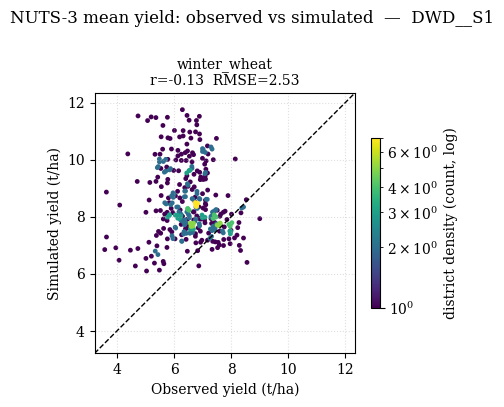

,crop,n,r,rmse,nrmse_pct,bias,mae
0,winter_wheat,344.0,-0.127,2.53,38.602,1.949,2.067


In [15]:
from matplotlib.colors import LogNorm


def point_density(x, y, bins=40):
    """Local point count for each (x, y) via a fast 2-D histogram lookup."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    H, xe, ye = np.histogram2d(x, y, bins=bins)
    ix = np.clip(np.digitize(x, xe) - 1, 0, H.shape[0] - 1)
    iy = np.clip(np.digitize(y, ye) - 1, 0, H.shape[1] - 1)
    return H[ix, iy]


# District climatology: mean obs & sim yield per district.
district_clim = {
    crop: df.groupby("NUTS_ID")
    .agg(yield_obs=("yield_obs", "mean"), yield_sim=("yield_sim", "mean"))
    .reset_index()
    for crop, df in comparison.items()
}

ncrops = len(comparison)
fig, axes = plt.subplots(1, ncrops, figsize=(4.2 * ncrops, 4.4), squeeze=False)
axes = axes[0]

sc = None
for ax, (crop, d) in zip(axes, district_clim.items()):
    dens = point_density(d["yield_obs"], d["yield_sim"])
    norm = LogNorm(vmin=1, vmax=max(dens.max(), 2))
    order = np.argsort(dens)
    sc = ax.scatter(
        d["yield_obs"].to_numpy()[order], d["yield_sim"].to_numpy()[order],
        c=dens[order], s=12, cmap="viridis", norm=norm, linewidths=0,
    )
    lo = min(d["yield_obs"].min(), d["yield_sim"].min()) * 0.9
    hi = max(d["yield_obs"].max(), d["yield_sim"].max()) * 1.05
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal")

    m = yield_metrics(d)
    ax.set_title(f"{crop}\nr={m['r']:.2f}  RMSE={m['rmse']:.2f}", fontsize=10)
    ax.set_xlabel("Observed yield (t/ha)")
    ax.grid(linestyle=":", alpha=0.4)

axes[0].set_ylabel("Simulated yield (t/ha)")
fig.colorbar(sc, ax=list(axes), shrink=0.5, label="district density (count, log)")
fig.suptitle(f"NUTS-3 mean yield: observed vs simulated  —  {SIM_NAME}", y=0.98)
plt.show()

# District-scale metrics table.
nuts_metrics = (
    pd.DataFrame({crop: yield_metrics(d) for crop, d in district_clim.items()})
    .T.rename_axis("crop").reset_index()
)
for col in ["r", "rmse", "nrmse_pct", "bias", "mae"]:
    nuts_metrics[col] = nuts_metrics[col].round(3)
nuts_metrics

## State scale — mean yield by federal state

Observed and simulated yields are averaged to each federal state (`STATE_NAME`).
The grouped bars per crop show state-level agreement; the annotated _r_ / RMSE are
computed across states.


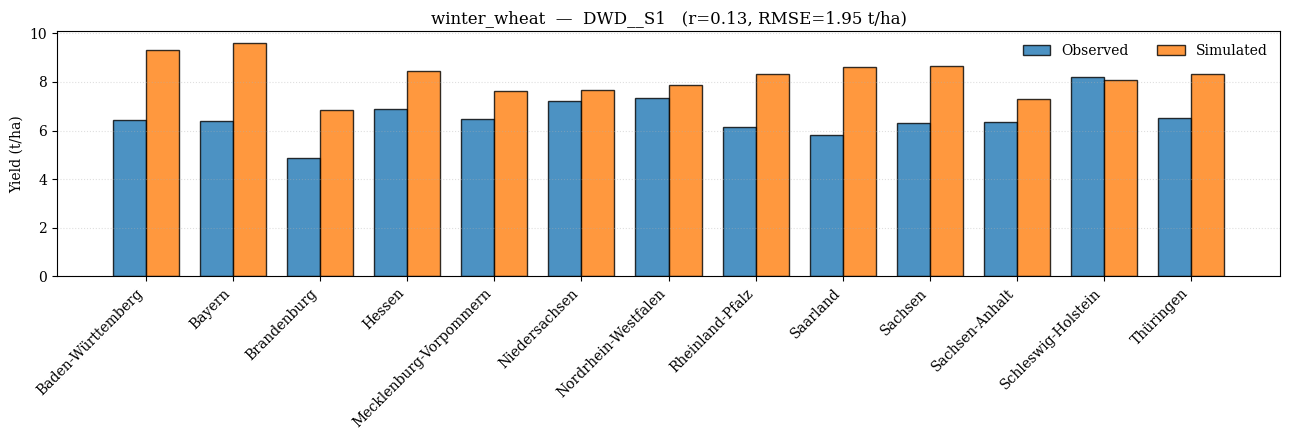

,crop,n,r,rmse,nrmse_pct,bias,mae
0,winter_wheat,13.0,0.13,1.946,29.779,1.673,1.694


In [18]:
state_clim = {}
for crop, df in comparison.items():
    st = (
        df.groupby("STATE_NAME")
        .agg(yield_obs=("yield_obs", "mean"), yield_sim=("yield_sim", "mean"))
        .reset_index()
        .sort_values("STATE_NAME")
    )
    state_clim[crop] = st

    states = st["STATE_NAME"]
    x = np.arange(len(states))
    width = 0.38

    fig, ax = plt.subplots(figsize=(13, 4.5))
    ax.bar(x - width / 2, st["yield_obs"], width, label="Observed",
           edgecolor="k", alpha=0.8)
    ax.bar(x + width / 2, st["yield_sim"], width, label="Simulated",
           edgecolor="k", alpha=0.8)
    ax.set_ylabel("Yield (t/ha)")
    ax.set_xticks(x)
    ax.set_xticklabels(states, rotation=45, ha="right")
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.legend(ncol=2, frameon=False)

    m = yield_metrics(st)
    ax.set_title(f"{crop}  —  {SIM_NAME}   (r={m['r']:.2f}, RMSE={m['rmse']:.2f} t/ha)")
    plt.tight_layout()
    plt.show()

# State-scale metrics table.
state_metrics = (
    pd.DataFrame({crop: yield_metrics(s) for crop, s in state_clim.items()})
    .T.rename_axis("crop").reset_index()
)
for col in ["r", "rmse", "nrmse_pct", "bias", "mae"]:
    state_metrics[col] = state_metrics[col].round(3)
state_metrics

## Yearly scale — inter-annual variability

Observed and simulated yields are averaged across all districts for each year
(±1 std across districts shown as error bars). This shows how well the simulation
tracks year-to-year variability; the annotated _r_ / RMSE are the **temporal**
agreement of the yearly means.


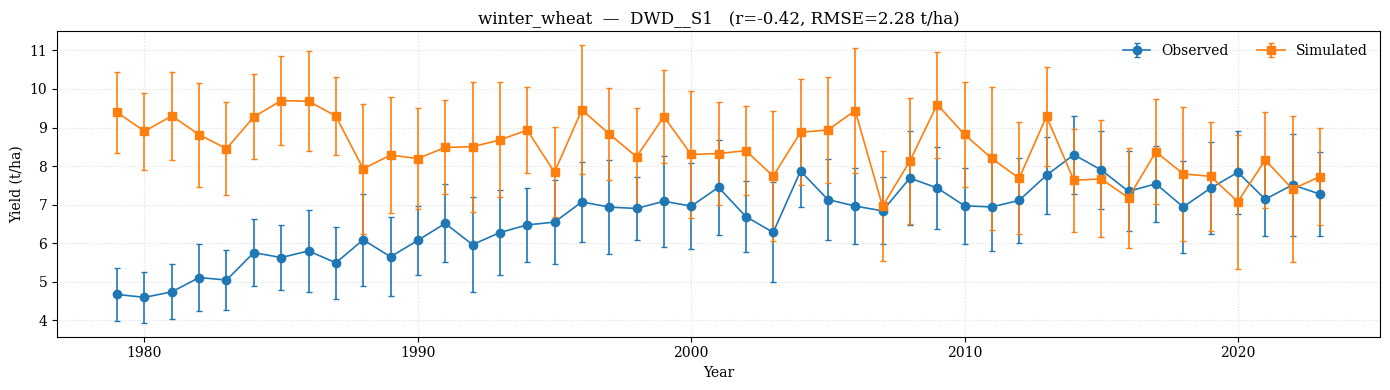

,crop,n,r,rmse,nrmse_pct,bias,mae
0,winter_wheat,45.0,-0.422,2.283,34.28,1.805,1.891


In [19]:
def yearly_stats(df: pd.DataFrame) -> pd.DataFrame:
    g = df.groupby("year")
    return pd.DataFrame(
        {
            "yield_obs": g["yield_obs"].mean(),
            "yield_obs_std": g["yield_obs"].std(),
            "yield_sim": g["yield_sim"].mean(),
            "yield_sim_std": g["yield_sim"].std(),
        }
    ).reset_index()


year_series = {}
for crop, df in comparison.items():
    ys = yearly_stats(df)
    year_series[crop] = ys
    years = ys["year"]

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.errorbar(years, ys["yield_obs"], yerr=ys["yield_obs_std"],
                marker="o", capsize=2, linewidth=1.2, label="Observed")
    ax.errorbar(years, ys["yield_sim"], yerr=ys["yield_sim_std"],
                marker="s", capsize=2, linewidth=1.2, label="Simulated")
    ax.set_ylabel("Yield (t/ha)")
    ax.set_xlabel("Year")
    ax.grid(linestyle=":", alpha=0.4)
    ax.legend(ncol=2, frameon=False)

    m = yield_metrics(ys)
    ax.set_title(f"{crop}  —  {SIM_NAME}   (r={m['r']:.2f}, RMSE={m['rmse']:.2f} t/ha)")
    plt.tight_layout()
    plt.show()

# Yearly-scale metrics table.
year_metrics = (
    pd.DataFrame({crop: yield_metrics(y) for crop, y in year_series.items()})
    .T.rename_axis("crop").reset_index()
)
for col in ["r", "rmse", "nrmse_pct", "bias", "mae"]:
    year_metrics[col] = year_metrics[col].round(3)
year_metrics

## Combined metrics across scales

Pearson _r_, RMSE and bias for every crop at each evaluation scale, side by side.
Correlation typically rises from the district-year level to the state and yearly
means as noise averages out. The full table is appended to `METRICS_CSV`.


In [20]:
tables = {
    "district-year": overall.drop(columns=["scale"]),
    "nuts3-clim": nuts_metrics,
    "state": state_metrics,
    "yearly": year_metrics,
}
combined = pd.concat(
    [t.assign(scale=name) for name, t in tables.items()], ignore_index=True
)
combined = combined[["crop", "scale", "n", "r", "rmse", "nrmse_pct", "bias", "mae"]]
combined.to_csv(METRICS_CSV, index=False)
print("Saved combined metrics to:", METRICS_CSV)

# Compact r / RMSE pivot for a quick read.
r_pivot = combined.pivot(index="crop", columns="scale", values="r").reindex(
    [c for c in CROPS if c in comparison]
)[["district-year", "nuts3-clim", "state", "yearly"]]
print("\nPearson r by crop and scale:")
r_pivot.round(2)

Saved combined metrics to: /beegfs/halder/GITHUB/RESEARCH/soil-amelioration-scenarios/data/processed/yield_metrics_DWD__S1.csv

Pearson r by crop and scale:


scale,district-year,nuts3-clim,state,yearly
crop,,,,
winter_wheat,-0.14,-0.13,0.13,-0.42
